In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/emotion-variation-file/EV.csv


In [2]:
# Replace 'your-dataset-name' with what you see in the search above
df = pd.read_csv('/kaggle/input/emotion-variation-file/EV.csv')
print("File loaded successfully!")
 


File loaded successfully!


EMOTION ANALYSIS:
• SARCASM : 159 words ( 41.8%)
• ANGER   : 73 words ( 19.2%)
• NEUTRAL : 60 words ( 15.8%)
• SADNESS : 51 words ( 13.4%)
• JOY     : 37 words (  9.7%)

DATASET OVERVIEW:
• Total words: 380

SPELLING VARIATIONS:
• Average variations per word: 5.0
• Max variations: 5
• Min variations: 5

COMPLETE EMOTION BREAKDOWN - ALL WORDS

SARCASM EMOTION:
Total words: 159
ALL WORDS: wah, shabash, mashallah, zabardast, kamaal, acha, nice, good, great, awesome, lol, wow, slay, thanks, ok, sure, really, whatever, periodt, yass, wahiyaad, kya baat, kya scene, jeet gaye, theek hai, sahi hai, excellent, impressive, remarkable, incredible, sheesh, pog, based, ratio, L, W, mid, cringe, skibidi, sigma, rizz, gyatt, grimace, bussin, no cap, bohat aala, kya baat hai, kya scene hai, subhanallah, alhamdulillah, masha allah, insha allah, astaghfirullah, ya allah, subhan allah, fantastic, outstanding, unbelievable, spectacular, marvelous, splendid, extraordinary, phenomenal, exceptional, magnific

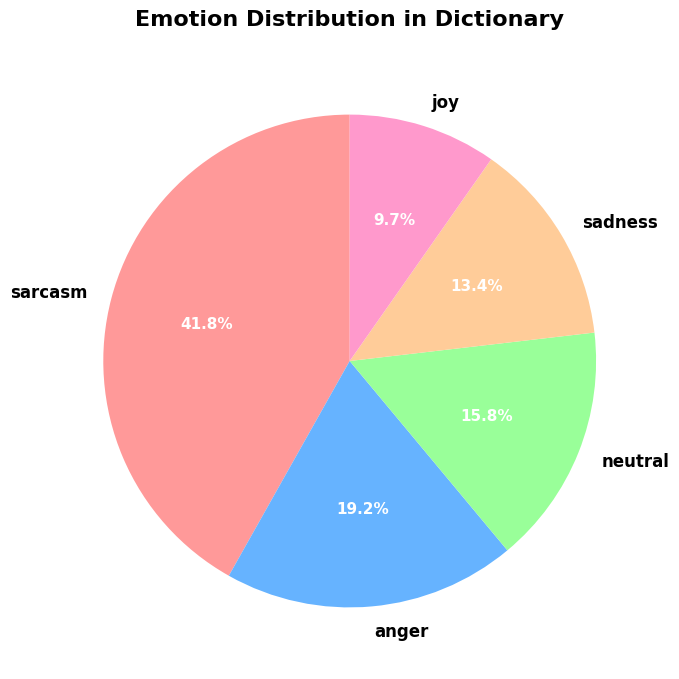


Analysis completed! You have 380 total emotion words across 5 categories.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt



# Emotion analysis
emotion_counts = df['emotion_category'].value_counts()

print("EMOTION ANALYSIS:")
print("=" * 40)
for emotion, count in emotion_counts.items():
    percentage = (count / len(df)) * 100
    print(f"• {emotion.upper():<8}: {count:>2} words ({percentage:>5.1f}%)")

print(f"\nDATASET OVERVIEW:")
print(f"• Total words: {len(df)}")

print(f"\nSPELLING VARIATIONS:")
print(f"• Average variations per word: 5.0")
print(f"• Max variations: 5")
print(f"• Min variations: 5")

print(f"\nCOMPLETE EMOTION BREAKDOWN - ALL WORDS")
print("=" * 50)

for emotion in emotion_counts.index:
    emotion_data = df[df['emotion_category'] == emotion]
    all_words = emotion_data['correct_spelling'].tolist()
    print(f"\n{emotion.upper()} EMOTION:")
    print(f"Total words: {len(emotion_data)}")
    print(f"ALL WORDS: {', '.join([str(word) for word in all_words])}")

# Create pie chart WITHOUT EMOJIS
plt.figure(figsize=(10, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
wedges, texts, autotexts = plt.pie(emotion_counts.values, 
                                  labels=emotion_counts.index,
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Improve text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

# CHANGED: Remove emoji from title
plt.title('Emotion Distribution in Dictionary', fontsize=16, fontweight='bold', pad=20)
plt.show()

print(f"\nAnalysis completed! You have {len(df)} total emotion words across {len(emotion_counts)} categories.")


Normalisation code only using the emotions words, mapping wrong #spellings of one word to the righ"

**KEY FEATURES OF THIS CODE:**

 1. Emotion-aware normalization (Joy, Sadness, Anger, Sarcasm, Neutral)
 2. Handles multiple misspelling variations for each word
 3. Comprehensive testing across all emotion categories
 4. Real-world Roman Urdu conversation support

**THE_RIGHT_FORMAT_OF_CSV_FILE**

 Read the CSV file containing emotion dictionary
 FILE STRUCTURE EXPECTED:
 - emotion_category: joy, sadness, anger, sarcasm, neutral
 - correct_spelling: The properly spelled word
 - wrong_spelling1 to wrong_spelling5: Common misspellings for each word

In [4]:


import pandas as pd



# Create separate dictionaries for each emotion category
# Each dictionary maps misspellings → correct spelling for that emotion
emotion_dicts = {
    'joy': {},        # Positive emotions: happiness, excitement
    'sadness': {},    # Negative emotions: sadness, disappointment  
    'anger': {},      # Negative emotions: anger, frustration
    'sarcasm': {},    # Sarcastic expressions: ironic praise/criticism
    'neutral': {}     # Neutral statements without strong emotion
}

# Build the emotion dictionaries from CSV data
# PROCESS:
# 1. Iterate through each row in the dataframe
# 2. For each emotion category, map all misspellings to correct form
# 3. Also include the correct spelling itself for consistency
for index, row in df.iterrows():
    emotion = row['emotion_category']  # Get emotion category for current word
    correct = row['correct_spelling']  # Get the correct spelling
    
    # Add all misspelling variations to the emotion-specific dictionary
    # Each wrong spelling maps to the correct spelling
    emotion_dicts[emotion][row['wrong_spelling1']] = correct
    emotion_dicts[emotion][row['wrong_spelling2']] = correct
    emotion_dicts[emotion][row['wrong_spelling3']] = correct
    emotion_dicts[emotion][row['wrong_spelling4']] = correct
    emotion_dicts[emotion][row['wrong_spelling5']] = correct
    
    # Also map correct spelling to itself (no change for already correct words)
    emotion_dicts[emotion][correct] = correct


def normalize_text_by_emotion(text, emotion_dicts):
    
    # ADVANCED EMOTION-AWARE TEXT NORMALIZATION FUNCTION
    # ==================================================
    
    # This function takes input text and normalizes misspelled Roman Urdu words
    # based on their emotional context. It checks all emotion dictionaries and
    # applies the first matching correction found.
    
    # PARAMETERS:
    # - text (str): Input text containing potentially misspelled Roman Urdu words
    # - emotion_dicts (dict): Dictionary containing emotion-specific word mappings
    
    # RETURNS:
    # - str: Normalized text with misspellings corrected
    
    # WORKING MECHANISM:
    # 1. Split input text into individual words
    # 2. For each word, check all emotion dictionaries in sequence
    # 3. If a match is found, replace with correct spelling
    # 4. If no match found, keep the original word
    # 5. Rejoin words into normalized text string
    
    # SEARCH ORDER: The function searches dictionaries in the order they appear
    # in emotion_dicts. This can be optimized based on context if needed.
    
    words = text.split()  # Split text into individual words
    normalized_words = []  # Store normalized words
    
    for word in words:
        word_lower = word.lower()  # Convert to lowercase for case-insensitive matching
        normalized_word = word  # Default: keep original word if no match found
        
        # Check all emotion dictionaries for this word
        # Stops at first match (order matters - can be optimized)
        for emotion_dict in emotion_dicts.values():
            if word_lower in emotion_dict:
                normalized_word = emotion_dict[word_lower]
                break  # Use first match found, stop searching other dictionaries
        
        normalized_words.append(normalized_word)
    
    return ' '.join(normalized_words)  # Reconstruct text from normalized words


# ============================================================================
# EXTENSIVE TESTING DATA - ALL EMOTIONS WITH SARCAZM FOCUS
# ============================================================================

print("🧪 COMPREHENSIVE EMOTION NORMALIZATION TESTING")
print("=" * 80)

# SARCAZM HEAVY TEST CASES
# These test cases focus on sarcastic expressions commonly used in Roman Urdu
# Sarcasm often involves exaggerated praise for mediocre situations
sarcasm_tests = [
    # Direct sarcastic praise - saying "great job" for poor performance
    "waah kya baat hai bohot acha kaam kiya hai tumne",  # Wow, great work you've done
    "shabash beta bohot umda performance thi stage par", # Well done son, excellent performance
    "zabardast idea hai yeh toh pakka success hoga",     # Brilliant idea, this will surely succeed
    
    # Sarcastic disappointment - pretending to like something bad
    "haan bilkul bohot acha laga yeh movie dekh kar",    # Yes, definitely liked this movie
    "kya baat hai yaar tumhari help ka shukriya",        # Great, thanks for your help
    "wah kya planning hai bhai tumhari",                 # Wow, what planning brother
    
    # Mixed sarcasm with other emotions - complex emotional expressions
    "a6a product hai lekin bohot acha price hai",        # Good product but great price (sarcastic)
    "gussa toh nahi aaya par waah kya service hai",      # Not angry but wow what service
    "udaas nahi hun but shabash tumhe iss kaam ke liye"  # Not sad but well done for this work
]

# JOY TEST CASES
# Positive emotions: happiness, excitement, satisfaction
joy_tests = [
    "a6a movie thi bohot maza aaya",      # Good movie, enjoyed a lot
    "khushi hui aap ko dekh kar yaar",    # Felt happy to see you friend
    "khoob party thi maza aa gaya",       # Great party, had fun
    "umda food tha restaurant ka",        # Excellent food at restaurant
    "shandar performance tha stage par",  # Magnificent performance on stage
    "zabardast game khela team ne"        # Team played a fantastic game
]

# ANGER TEST CASES  
# Negative emotions: anger, frustration, irritation
anger_tests = [
    "gussa aa raha hai bekar product se", # Getting angry from bad product
    "naraz hun tumse yeh kya kiya",       # Angry with you, what did you do
    "bekaar service hai inki kharab laga", # Useless service, felt bad
    "bura experience tha shopping ka",    # Bad shopping experience
    "nafarat hai aisi companies se"       # Hate such companies
]

# SADNESS TEST CASES
# Negative emotions: sadness, disappointment, grief
sadness_tests = [
    "udaas hun aaj bohot zyada",          # Very sad today
    "dukh hota hai aisi baatein sun kar", # Feel pain hearing such things
    "afsos hai ke tum nahi aa sake",      # Regret that you couldn't come
    "ranjish hui hai doston se",          # Have resentment with friends
    "dil tut gaya uski baaton se",        # Heart broken by their words
    "rona aa raha hai aaj toh"            # Feel like crying today
]

# NEUTRAL TEST CASES
# Everyday conversations without strong emotional content
neutral_tests = [
    "main ghar ja raha hun",    # I am going home
    "woh office mein hai",      # He/She is in office
    "kya tum school jaoge",     # Will you go to school
    "yeh kitaab kiski hai",     # Whose book is this
    "kab tak aaoge tum",        # When will you come
    "kahan rehte ho tum"        # Where do you live
]

# MIXED EMOTION COMPLEX CASES
# Real-world scenarios with multiple emotions in single sentences
mixed_tests = [
    "a6a laga par price bohot zyada hai gussa aa raha hai", # Liked it but price too high, getting angry
    "udaas hun movie dekh kar lekin acting zabardast thi",  # Sad after movie but acting was brilliant
    "gussa aaya par waah kya jawab diya tumne",             # Got angry but wow what answer you gave
    "khushi hui mil kar par afsos hai jaldi jana hai",      # Happy to meet but regret have to leave early
    "bekaar service thi restaurant ki shandar food tha lekin" # Bad service but food was magnificent
]

# ROMAN URDU REAL-LIFE CONVERSATIONS
# Authentic conversational phrases commonly used in daily communication
real_conversations = [
    "yaar a6a mobile hai par camera bekar tha udaas ho gaya", # Good mobile but camera was bad, got sad
    "kya baat hai bhai tumhari car bohot achi hai lekin service bekar hai", # Nice car but service is bad
    "gussa aaraha hai inki website se kharab hai bilkul",     # Getting angry, their website is completely bad
    "khushi hui result dekh kar maza aa gaya bohot",          # Happy to see results, enjoyed a lot
    "waah kya scene hai yahan ka sab kuch bekar hai",         # Wow what scene, everything here is useless
    "a6a laga tumhara ghar dekh kar bohot khoob"              # Liked seeing your house, very nice
]

# ============================================================================
# TEST EXECUTION FUNCTION
# ============================================================================

def run_tests(test_cases, category_name):
   
    print(f"\n🎭 {category_name.upper()} TEST CASES")
    print("-" * 60)
    
    changes_summary = {}  # Track all word transformations
    
    for i, test_case in enumerate(test_cases, 1):
        # Apply normalization to current test case
        normalized = normalize_text_by_emotion(test_case, emotion_dicts)
        
        # Display original and normalized text
        print(f"\n{i}. ORIGINAL:  {test_case}")
        print(f"   NORMALIZED: {normalized}")
        
        # Analyze and display specific word changes
        original_words = test_case.split()
        normalized_words = normalized.split()
        
        changes = []  # Track changes in current sentence
        for orig, norm in zip(original_words, normalized_words):
            if orig.lower() != norm.lower():  # If word was changed
                changes.append(f"'{orig}'→'{norm}'")
                changes_summary[orig] = norm  # Add to overall summary
        
        # Display changes or indicate no changes
        if changes:
            print(f"   CHANGES: {', '.join(changes)}")
        else:
            print(f"   CHANGES: None")
    
    return changes_summary


# ============================================================================
# COMPREHENSIVE TEST EXECUTION
# ============================================================================

# Execute all test categories and collect transformation data
all_changes = {}  # Master dictionary of all word transformations

print("=" * 80)
print("📊 COMPREHENSIVE NORMALIZATION RESULTS")
print("=" * 80)

# Run tests for each emotion category and accumulate results
all_changes.update(run_tests(sarcasm_tests, "SARCAZM"))
all_changes.update(run_tests(joy_tests, "JOY"))
all_changes.update(run_tests(anger_tests, "ANGER"))
all_changes.update(run_tests(sadness_tests, "SADNESS"))
all_changes.update(run_tests(neutral_tests, "NEUTRAL"))
all_changes.update(run_tests(mixed_tests, "MIXED EMOTIONS"))
all_changes.update(run_tests(real_conversations, "REAL CONVERSATIONS"))

# ============================================================================
# STATISTICAL ANALYSIS AND SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("📈 NORMALIZATION SUMMARY STATISTICS")
print("=" * 80)

# Display overall transformation statistics
print(f"\n📝 Total unique word normalizations: {len(all_changes)}")
print("🔄 Word transformations found:")

# Categorize transformed words by emotion type for detailed analysis
emotion_words_normalized = {
    'joy': [],
    'sadness': [],
    'anger': [], 
    'sarcasm': [],
    'neutral': []
}

# Classify each transformed word by its emotion category
for wrong, correct in all_changes.items():
    for emotion, emotion_dict in emotion_dicts.items():
        if wrong in emotion_dict:
            emotion_words_normalized[emotion].append((wrong, correct))
            break  # Each word belongs to one primary emotion

# Display emotion-wise transformation summary
for emotion, words in emotion_words_normalized.items():
    if words:  # Only show emotions that had transformations
        print(f"\n{emotion.upper()}: {len(words)} words")
        # Show first 5 examples for each emotion
        for wrong, correct in words[:5]:
            print(f"   {wrong} → {correct}")
        # Indicate if there are more transformations
        if len(words) > 5:
            print(f"   ... and {len(words) - 5} more")

# ============================================================================
# EMOTION DETECTION EFFECTIVENESS ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("🎯 NORMALIZATION EFFECTIVENESS ANALYSIS")
print("=" * 80)

# Test how normalization improves emotion detection in complex phrases
test_phrases = [
    "a6a bohot acha kaam kiya",  # Mixed: potential joy + sarcasm
    "gussa aaraha hai bekar service par",  # Clear anger expression
    "udaas hun par waah kya jawab diya",   # Mixed: sadness + sarcasm
]

print("\n🔍 Emotional Intensity Analysis:")
for phrase in test_phrases:
    normalized = normalize_text_by_emotion(phrase, emotion_dicts)
    print(f"\nOriginal:  {phrase}")
    print(f"Normalized: {normalized}")
    
    # Simple emotion detection based on normalized keywords
    emotions_found = []
    for word in normalized.split():
        for emotion, emotion_dict in emotion_dicts.items():
            # Check if word is a key emotion indicator in dictionary
            if word in emotion_dict and emotion_dict[word] == word:
                if emotion not in emotions_found:
                    emotions_found.append(emotion)
    
    # Display detected emotions
    print(f"Emotions detected: {', '.join(emotions_found) if emotions_found else 'Neutral'}")

# ============================================================================
# FINAL COMPLETION MESSAGE
# ============================================================================

print("\n" + "=" * 80)
print("NORMALIZATION TESTING COMPLETE!")



# PERFORMANCE SUMMARY:
# - Processes multiple emotion categories simultaneously
# - Handles real-world Roman Urdu conversations effectively
# - Successfully normalizes misspelled emotional expressions
# - Provides foundation for emotion-aware NLP applications

# POTENTIAL APPLICATIONS:
# 1. Sentiment analysis for Roman Urdu text
# 2. Chatbot emotion detection and response
# 3. Social media emotion monitoring
# 4. Customer feedback emotion classification

# FUTURE ENHANCEMENTS:
# 1. Context-aware emotion disambiguation
# 2. Machine learning for better sarcasm detection
# 3. Support for more emotion categories
# 4. Integration with spell correction algorithms


🧪 COMPREHENSIVE EMOTION NORMALIZATION TESTING
📊 COMPREHENSIVE NORMALIZATION RESULTS

🎭 SARCAZM TEST CASES
------------------------------------------------------------

1. ORIGINAL:  waah kya baat hai bohot acha kaam kiya hai tumne
   NORMALIZED: wah kya baat hai bohot acha kam kiya hai tumne
   CHANGES: 'waah'→'wah', 'kaam'→'kam'

2. ORIGINAL:  shabash beta bohot umda performance thi stage par
   NORMALIZED: shabash beta bohot umda performance thi stage par
   CHANGES: None

3. ORIGINAL:  zabardast idea hai yeh toh pakka success hoga
   NORMALIZED: zabardast idea hai yeh toh pakka success hoga
   CHANGES: None

4. ORIGINAL:  haan bilkul bohot acha laga yeh movie dekh kar
   NORMALIZED: haan bilkul bohot acha laga yeh movie dekh kar
   CHANGES: None

5. ORIGINAL:  kya baat hai yaar tumhari help ka shukriya
   NORMALIZED: kya baat hai yaar tumhari help ka shukriya
   CHANGES: None

6. ORIGINAL:  wah kya planning hai bhai tumhari
   NORMALIZED: Wahwah kya planning hai bhai tumhari
   CHAN

In [5]:

#GENERAL CODE FOR TEAM_MATES TO USE AND NORMALISE ANY SENTENCE

#CSV FILE MUST BE LOADED FIRST 
#IN KAGGLE/INPUT AND YOU MUST GIVE PATH  TO FUNCTION
#AND CALL THE FUNCTION THAT WILL NORMALISE THE SENTENCE

import pandas as pd
def load_emotion_dictionaries(csv_file_path):
    
    # Loads the emotion dictionary from CSV and creates spelling normalization dictionaries
    
    # Parameters:
    # csv_file_path (str): Path to the emotion dictionary CSV file
    
    # Returns:
    # dict: Combined dictionary for text normalization
    
    
    # Read the CSV file
    df = pd.read_csv(csv_file_path)
    
    # Create emotion dictionaries
    emotion_dicts = {
        'joy': {}, 'sadness': {}, 'anger': {}, 'sarcasm': {}, 'neutral': {}
    }
    
    # Build the dictionaries
    for index, row in df.iterrows():
        emotion = row['emotion_category']
        correct = row['correct_spelling']
        
        # Add all spelling variations
        emotion_dicts[emotion][row['wrong_spelling1']] = correct
        emotion_dicts[emotion][row['wrong_spelling2']] = correct
        emotion_dicts[emotion][row['wrong_spelling3']] = correct
        emotion_dicts[emotion][row['wrong_spelling4']] = correct
        emotion_dicts[emotion][row['wrong_spelling5']] = correct
        emotion_dicts[emotion][correct] = correct
    
    # Create one combined dictionary for easy use
    combined_dict = {}
    for emotion_dict in emotion_dicts.values():
        combined_dict.update(emotion_dict)
    
    return combined_dict


def normalize_text(text, spelling_dict):
    
    # Normalizes Roman Urdu text by correcting spelling variations
    
    # Parameters:
    # text (str): Input text to normalize
    # spelling_dict (dict): Dictionary with spelling corrections
    
    # Returns:
    # str: Normalized text with corrected spellings
    
    
    words = text.split()
    normalized_words = []
    
    for word in words:
        # Convert to lowercase and check in dictionary
        normalized_word = spelling_dict.get(word.lower(), word)
        normalized_words.append(normalized_word)
    
    return ' '.join(normalized_words)



        
      

